# Access MAST data example notebook

This notebook selects 50 random shots from the MAST dataset (found at "https://mastapp.site/parquet/level2/shots.parquet"), retrieves 0D scalar data for those shots, and saves the data locally to a .nc save file.

It also provides an example of how to handle that scalar data within an Xarray Dataset.

### Select the random list of shots to pull data for

In [19]:
# use Pandas to load shot IDs form the online parquet file
import pandas as pd
shot_list = pd.read_parquet("https://mastapp.site/parquet/level2/shots.parquet").shot_id.values

# select 50 random shots
import random
sublist = random.sample(shot_list.tolist(),50)

### Use Disruption-Py to load the scalar data and store it as an Xarray Dataset

In [20]:
from disruption_py.settings import LogSettings, RetrievalSettings
from disruption_py.workflow import get_shots_data

# set the Disruption-Py retreival settings
retrieval_settings = RetrievalSettings(
    time_setting="disruption_warning",  # use the 'disruption-warning' efit time-base for this dataset
)

# load the data into an Xarray Dataset
db_stacked = get_shots_data(
    shotlist_setting=sublist,               # list of shots to retrieve data for
    tokamak="mast",                         # tokamak to access data from
    retrieval_settings=retrieval_settings,  # retrieval settings set above
    output_setting="mast_data.nc",          # output file name/path
    num_processes=20,
    log_settings=LogSettings(               # logger settings
        file_path=None,
        file_level="DEBUG",
        console_level=None,
    ),
)

db_stacked

14:24:06.910 [ INFO  ] Starting: disruption_py ~ v0.14.0.dev0 # d7d1b9ef2883b85fe2207831588360bde3dda271 / saperstein@mfews10
14:24:06.911 [ INFO  ] Resolved tokamak: MAST
14:24:06.911 [ INFO  ] Imported MDSplus.
14:24:06.916 [VERBOSE] Dumped configuration: /tmp/saperstein/disruption-py/2026-03-02/13.55.11-y0yz8vf8/config.json
14:24:06.927 [ INFO  ] Starting workflow: 50 shots / 20 processes


  0%|          | 0/50 [00:00<?, ?it/s]

14:24:21.987 [VERBOSE] #13505 | 0.520s : get_ip_parameters
14:24:22.103 [VERBOSE] #17561 | 0.636s : get_ip_parameters
14:24:22.111 [VERBOSE] #24722 | 0.531s : get_ip_parameters
14:24:22.112 [VERBOSE] #24722 | 0.533s : get_time_domain
14:24:22.181 [VERBOSE] #27429 | 0.499s : get_ip_parameters
14:24:22.230 [VERBOSE] #23716 | 0.490s : get_ip_parameters
14:24:22.232 [VERBOSE] #23716 | 0.492s : get_time_domain
14:24:22.338 [VERBOSE] #27910 | 0.598s : get_ip_parameters
14:24:22.432 [VERBOSE] #28279 | 0.651s : get_ip_parameters
14:24:22.778 [VERBOSE] #20630 | 0.710s : get_ip_parameters
14:24:22.816 [VERBOSE] #29352 | 0.488s : get_ip_parameters
14:24:23.041 [VERBOSE] #15645 | 0.492s : get_ip_parameters
14:24:23.043 [VERBOSE] #15645 | 0.495s : get_time_domain
14:24:23.071 [VERBOSE] #18634 | 0.980s : get_ip_parameters
14:24:23.125 [VERBOSE] #21699 | 0.603s : get_ip_parameters
14:24:23.127 [VERBOSE] #21699 | 0.606s : get_time_domain
14:24:23.195 [VERBOSE] #17722 | 0.694s : get_ip_parameters
14:24

<xarray.Dataset> Size: 3MB
Dimensions:             (idx: 19993)
Coordinates:
    shot                (idx) int64 160kB 11952 11952 11952 ... 30416 30416
    time                (idx) float32 80kB 0.0 0.001 0.002 ... 0.351 0.352 0.353
Dimensions without coordinates: idx
Data variables: (12/33)
    a_minor             (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    beta_n              (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    beta_p              (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    beta_t              (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    bphi_rmag           (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    bvac_rmag           (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    ...                  ...
    time_domain         (idx) float32 80kB 1.0 1.0 1.0 1.0 ... 2.0 2.0 2.0 2.0
    tribot              (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    tritop              (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    v_loop_dynamic      (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    v_loop_static       (idx) float32 80kB nan nan nan nan ... nan nan nan nan
    wmhd                (idx) float32 80kB nan nan nan nan ... nan nan nan nan
Attributes:
    tokamak:  MAST
    user:     saperstein
    host:     mfews10
    time:     2026-03-02T13:55:21.727063
    package:  disruption_py
    version:  0.14.0.dev0
    commit:   d7d1b9ef2883b85fe2207831588360bde3dda271
    source:   https://github.com/MIT-PSFC/disruption-py/tree/d7d1b9ef2883b85f...

### (optional) Load locally saved data instead

In [21]:
import xarray as xr

db_stacked = xr.open_dataset("mast_data.nc")
db_stacked

<xarray.Dataset> Size: 3MB
Dimensions:             (idx: 19993)
Coordinates:
    shot                (idx) int64 160kB ...
    time                (idx) float32 80kB ...
Dimensions without coordinates: idx
Data variables: (12/33)
    a_minor             (idx) float32 80kB ...
    beta_n              (idx) float32 80kB ...
    beta_p              (idx) float32 80kB ...
    beta_t              (idx) float32 80kB ...
    bphi_rmag           (idx) float32 80kB ...
    bvac_rmag           (idx) float32 80kB ...
    ...                  ...
    time_domain         (idx) float32 80kB ...
    tribot              (idx) float32 80kB ...
    tritop              (idx) float32 80kB ...
    v_loop_dynamic      (idx) float32 80kB ...
    v_loop_static       (idx) float32 80kB ...
    wmhd                (idx) float32 80kB ...
Attributes:
    tokamak:  MAST
    user:     saperstein
    host:     mfews10
    time:     2026-03-02T13:55:21.727063
    package:  disruption_py
    version:  0.14.0.dev0
    commit:   d7d1b9ef2883b85fe2207831588360bde3dda271
    source:   https://github.com/MIT-PSFC/disruption-py/tree/d7d1b9ef2883b85f...

### Unstack the dataset

Disruption-Py returns the Xarray Dataset with a single dimension called 'idx', which corresponds to a unique shot-time set.

'shot' and 'time' can be converted explicitly into dimensions by unstacking the dataset. This makes slicing the data more convenient.

In [22]:
db = db_stacked.set_index(idx=("shot","time")).unstack("idx")
db

<xarray.Dataset> Size: 4MB
Dimensions:             (shot: 50, time: 642)
Coordinates:
  * shot                (shot) int64 400B 11952 12870 12927 ... 29754 30416
  * time                (time) float32 3kB 0.0 0.001 0.002 ... 0.639 0.64 0.641
Data variables: (12/33)
    a_minor             (shot, time) float32 128kB nan nan nan ... nan nan nan
    beta_n              (shot, time) float32 128kB nan nan nan ... nan nan nan
    beta_p              (shot, time) float32 128kB nan nan nan ... nan nan nan
    beta_t              (shot, time) float32 128kB nan nan nan ... nan nan nan
    bphi_rmag           (shot, time) float32 128kB nan nan nan ... nan nan nan
    bvac_rmag           (shot, time) float32 128kB nan nan nan ... nan nan nan
    ...                  ...
    time_domain         (shot, time) float32 128kB 1.0 1.0 1.0 ... nan nan nan
    tribot              (shot, time) float32 128kB nan nan nan ... nan nan nan
    tritop              (shot, time) float32 128kB nan nan nan ... nan nan nan
    v_loop_dynamic      (shot, time) float32 128kB nan nan nan ... nan nan nan
    v_loop_static       (shot, time) float32 128kB nan nan nan ... nan nan nan
    wmhd                (shot, time) float32 128kB nan nan nan ... nan nan nan
Attributes:
    tokamak:  MAST
    user:     saperstein
    host:     mfews10
    time:     2026-03-02T13:55:21.727063
    package:  disruption_py
    version:  0.14.0.dev0
    commit:   d7d1b9ef2883b85fe2207831588360bde3dda271
    source:   https://github.com/MIT-PSFC/disruption-py/tree/d7d1b9ef2883b85f...

## Plotting

### Select a subset of (random) shots to plot data for

In [23]:
import random
import numpy as np

n_shots = 3 # number of shots to plot
SEED = 32   # random seed

random.seed(SEED)
shot_list = np.sort(random.sample(np.unique(db.shot.values).tolist(), n_shots))
random.seed()

subset = db.sel(shot=shot_list) # subset to be plotted
subset

<xarray.Dataset> Size: 257kB
Dimensions:             (shot: 3, time: 642)
Coordinates:
  * shot                (shot) int64 24B 13505 16731 18634
  * time                (time) float32 3kB 0.0 0.001 0.002 ... 0.639 0.64 0.641
Data variables: (12/33)
    a_minor             (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    beta_n              (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    beta_p              (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    beta_t              (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    bphi_rmag           (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    bvac_rmag           (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    ...                  ...
    time_domain         (shot, time) float32 8kB 1.0 1.0 1.0 1.0 ... nan nan nan
    tribot              (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    tritop              (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    v_loop_dynamic      (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    v_loop_static       (shot, time) float32 8kB nan nan nan nan ... nan nan nan
    wmhd                (shot, time) float32 8kB nan nan nan nan ... nan nan nan
Attributes:
    tokamak:  MAST
    user:     saperstein
    host:     mfews10
    time:     2026-03-02T13:55:21.727063
    package:  disruption_py
    version:  0.14.0.dev0
    commit:   d7d1b9ef2883b85fe2207831588360bde3dda271
    source:   https://github.com/MIT-PSFC/disruption-py/tree/d7d1b9ef2883b85f...

### Generate plot for each signal

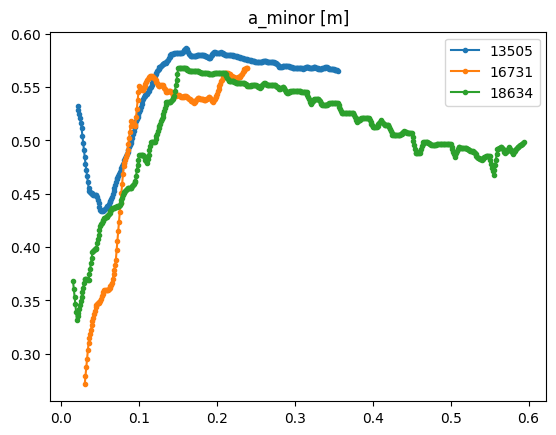

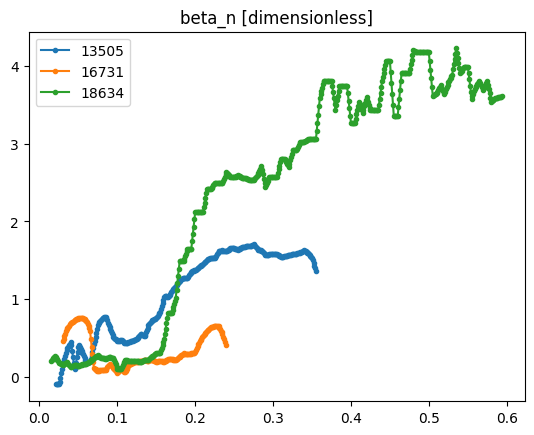

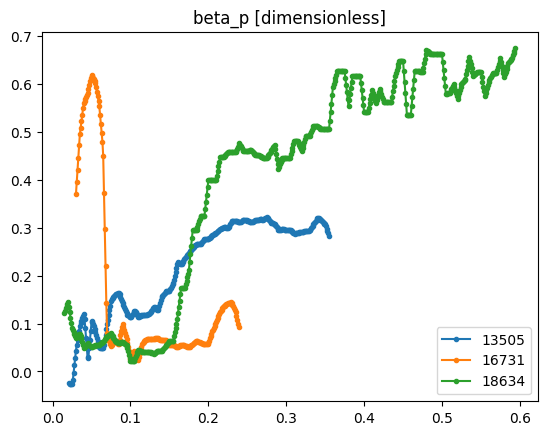

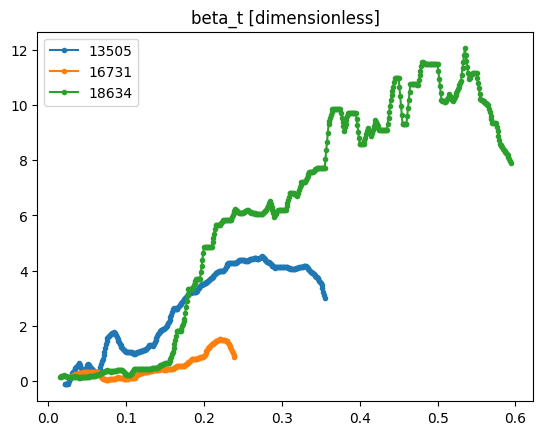

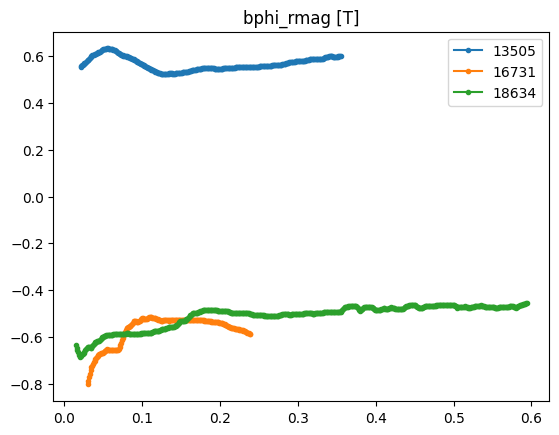

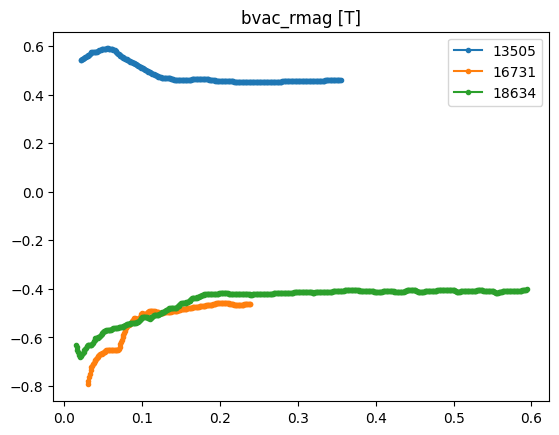

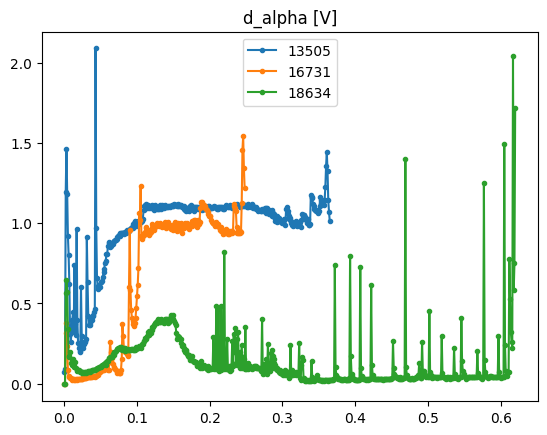

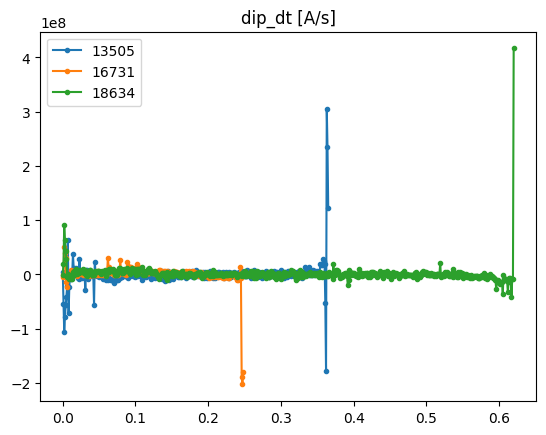

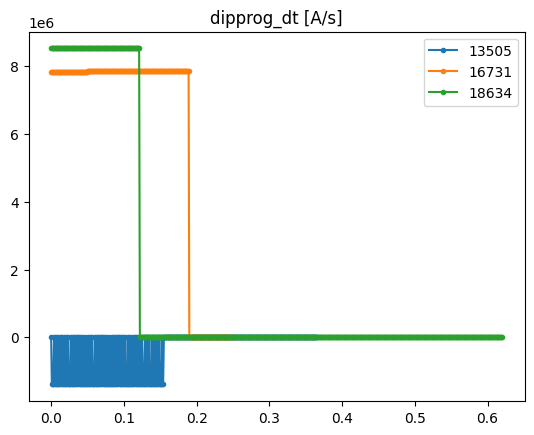

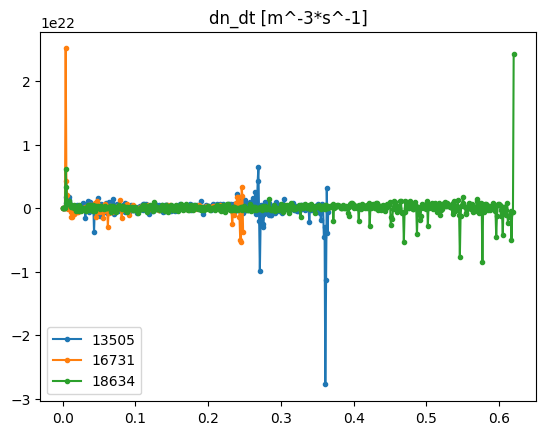

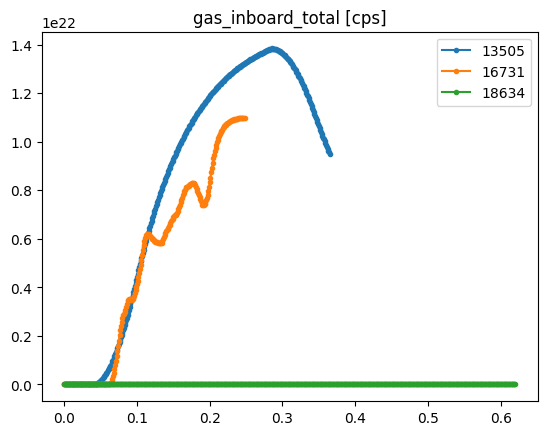

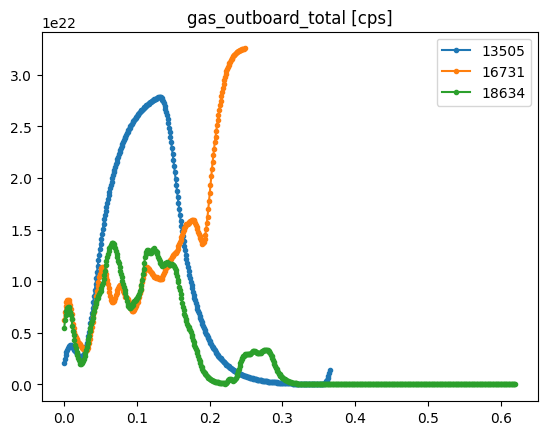

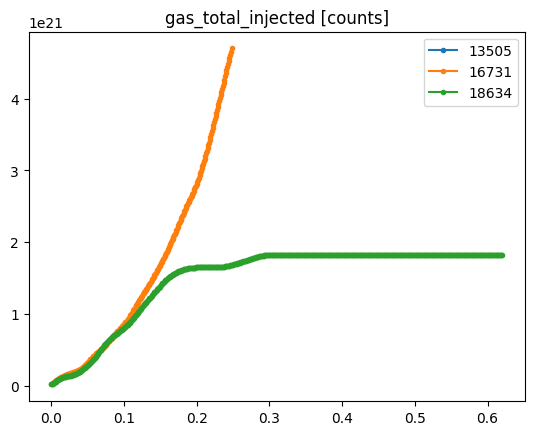

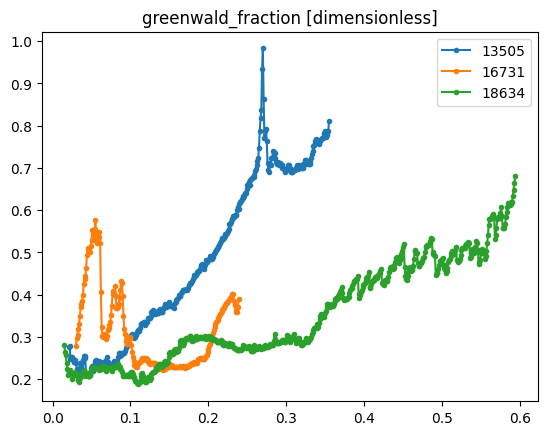

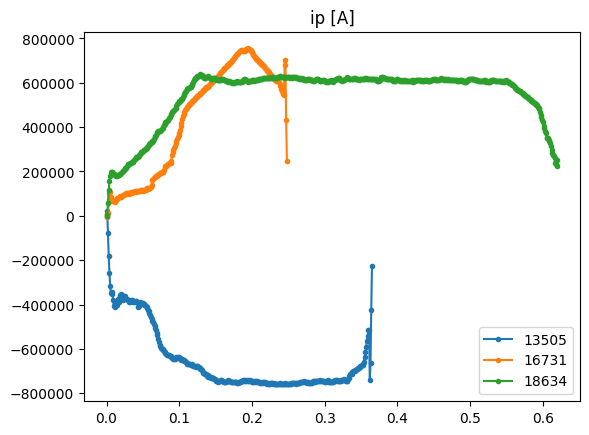

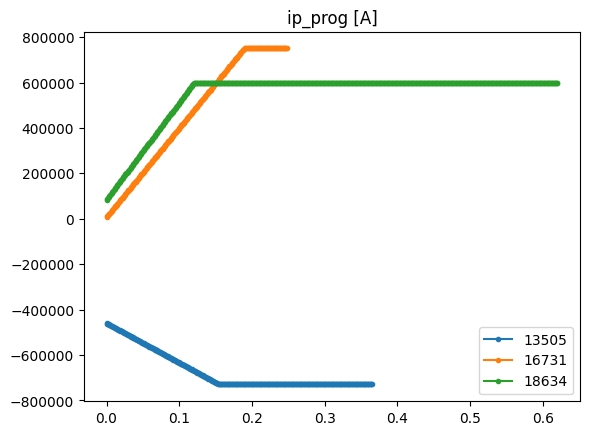

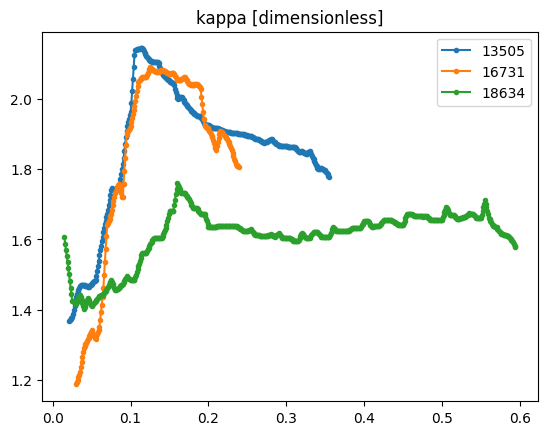

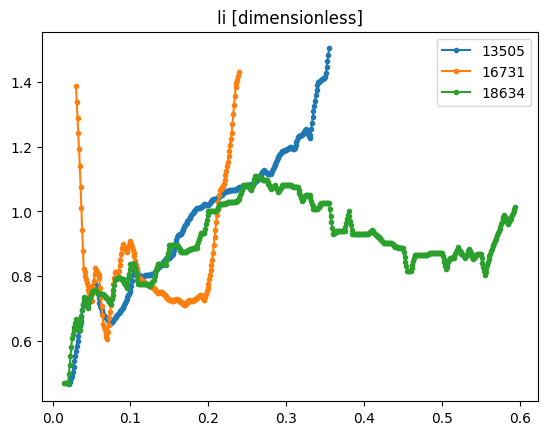

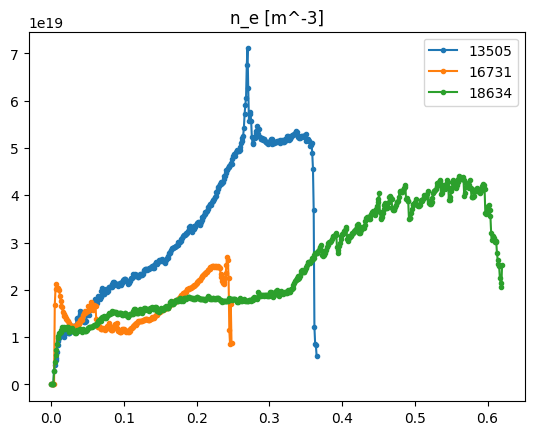

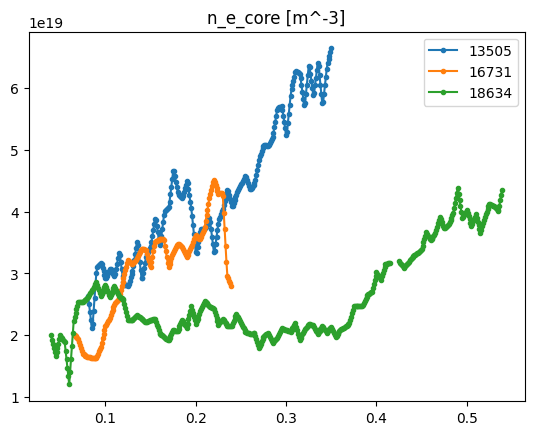

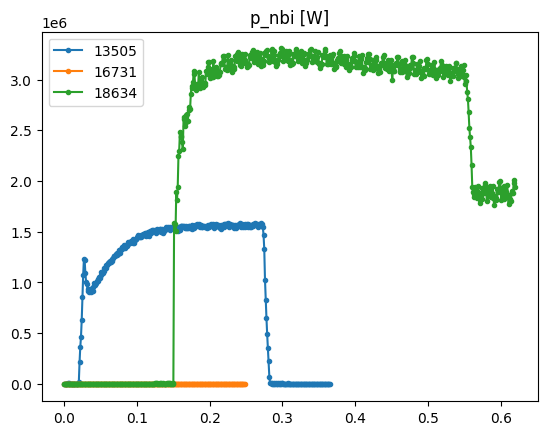

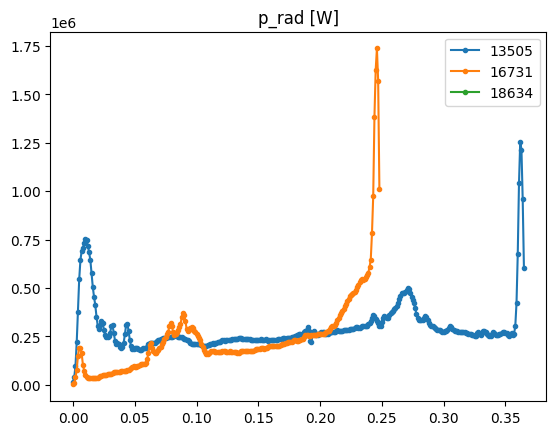

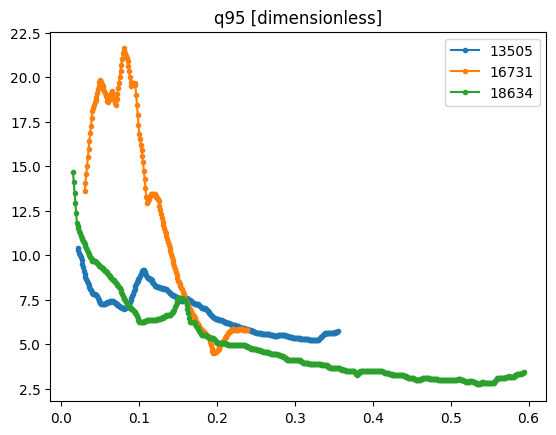

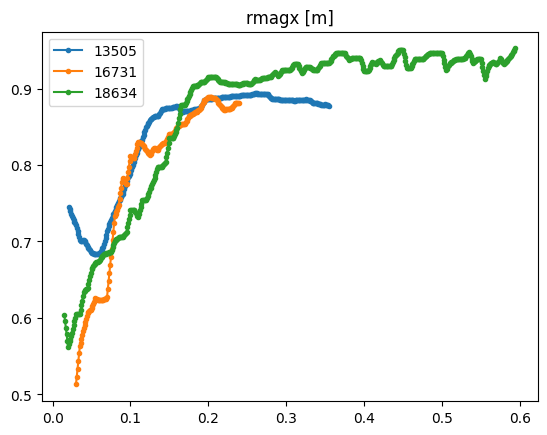

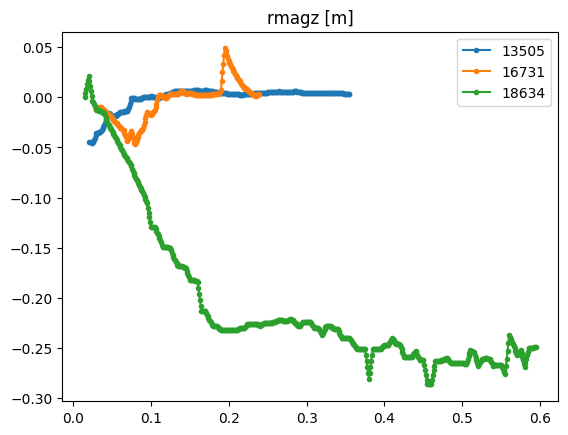

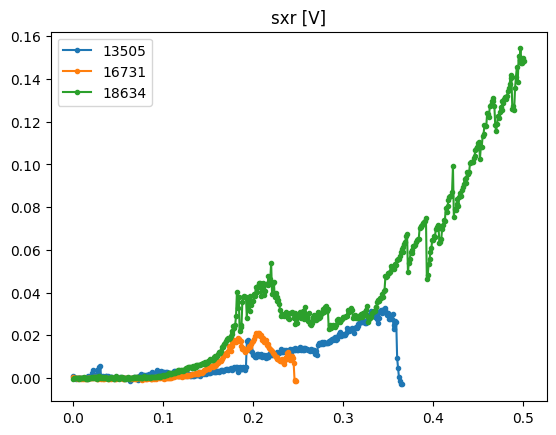

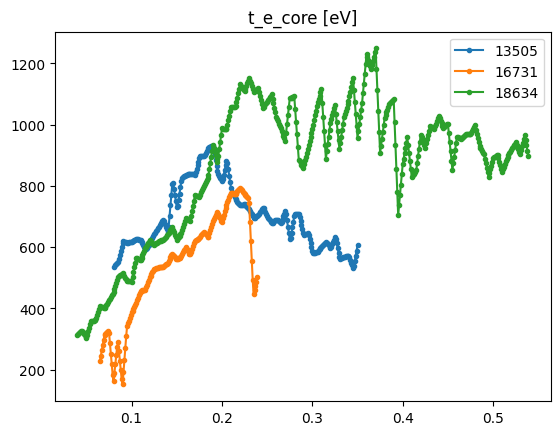

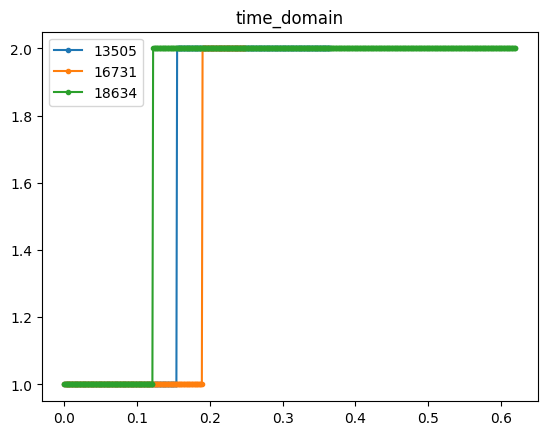

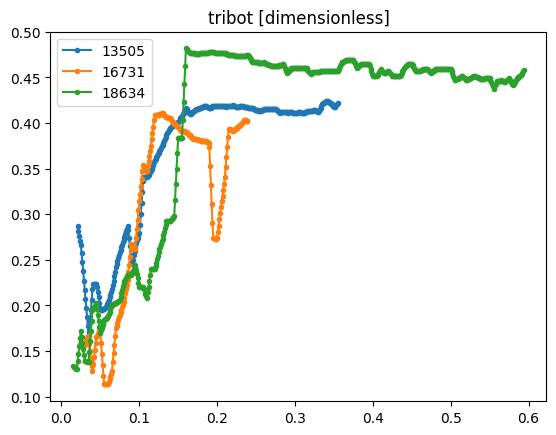

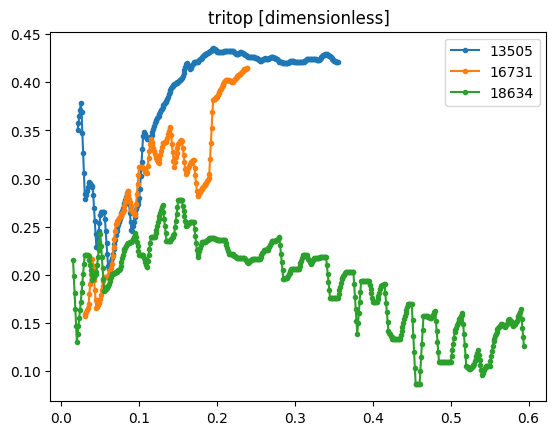

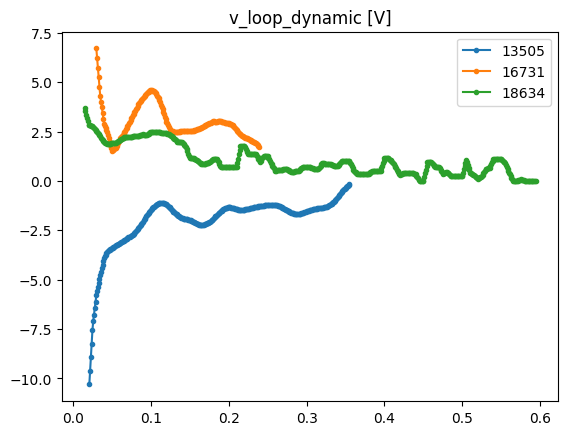

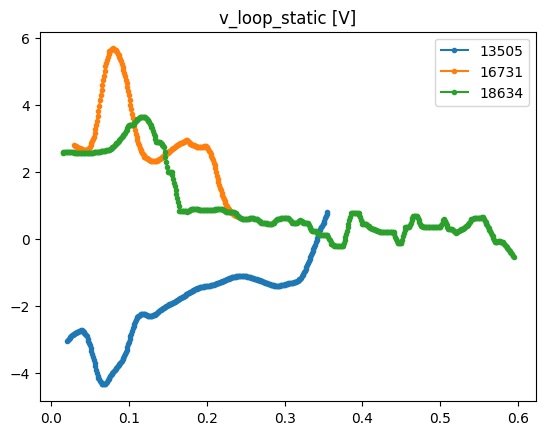

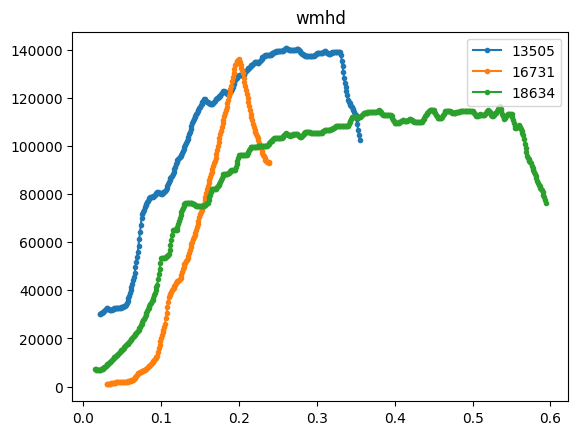

In [28]:
import matplotlib.pyplot as plt

features = list(subset.data_vars.keys())    # list of features to plot (all in Disruption-Py)

for ff,feat in enumerate(features):
    for shot in shot_list:
        shot_data = subset.sel(shot=shot)   # down-select data to only a single shot
        plt.plot(shot_data.time, shot_data[feat], marker='.', label=shot)
    
    plt.legend()
    if 'units' in subset[feat].attrs:
        plt.title(f"{feat} [{subset[feat].attrs['units']}]")    # information for each feature, like 'units' is stored in the .attrs
    else:
        plt.title(f"{feat}")
    plt.show()